# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [275]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
import multiprocessing
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import DirectedGraph, UndirectedGraph
from NEMtropy import matrix_generator as mg
from NEMtropy.network_functions import build_adjacency_from_edgelist


In [276]:
SEED = 42

In [277]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_GREEN = 'palegreen'
COLOR_RED = 'lightcoral'
COLOR_YELLOW = 'gold'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [278]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
### OUTPUT_PATH_ERGMS = os.path.join(OUTPUT_PATH, "ERGMs")


# Recreate the subdirectories
### os.makedirs(OUTPUT_PATH_ERGMS)

In [279]:
# Define the directory containing the .gml files
directory = 'datasets'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files: 100%|██████████| 4/4 [00:00<00:00, 14.24it/s]

Finished loading graph_jazz_collab
Finished loading graph1.2
Finished loading graph1.1
Finished loading graph_madrid


# 1. Compartmental Models on Networks

## 1.1 
Write a function to simulate the SI dynamic on a generic network and provide a visualisation.
The function should take in input:
- a network, e.g. if you are using networkx a generic nx.Graph,
- the infection rate β,
- an infected seed node.

You may also want to add other parameters, e.g. the maximum number of steps for the simulation (some
bad things may happen if you don’t). As an output, the function should return the list of nodes infected
in the simulation. Additionally, run the SI function for an adequate number of steps, with β = 0.5 on
the following two graphs (the datasets are provided), with infected seed node “10”:
- graph1.1.gml
- graph1.2.gml

and provide a visualisation of the final state of the epidemic, where all the infected nodes at the end of
the run are red, or blue if they are not infected.

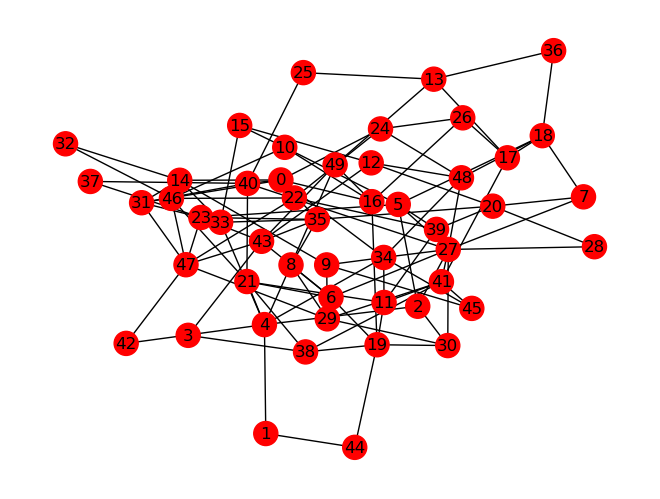

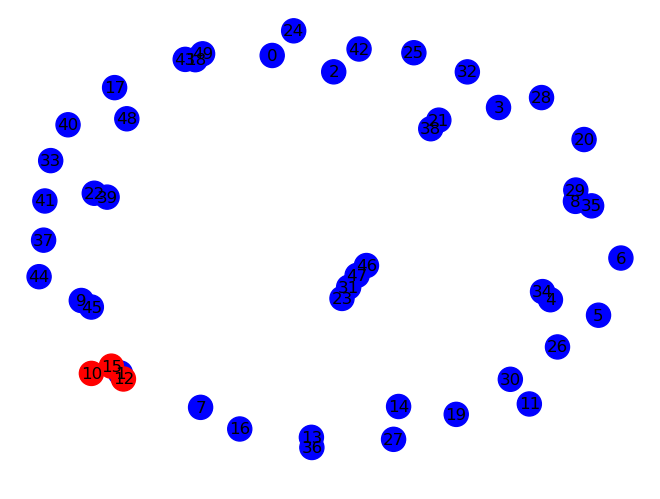

In [280]:
def si_simulation(graph, beta, seed_node, max_steps=100):
    # Set of infected nodes with the seed node
    infected_nodes = set()
    infected_nodes.add(seed_node)

    nodes = set(graph.nodes) # Set of all nodes in the graph
    steps = 0

    while steps < max_steps:
        cp_infected_nodes = infected_nodes.copy()
        susceptible_nodes = nodes - cp_infected_nodes # Identify susceptible nodes by subtracting infected nodes from all nodes

        for node in susceptible_nodes:
            neighbors = set(graph.neighbors(node)) # Get neighbors of current node
            infected_neighbors = neighbors & cp_infected_nodes # Get infected neighbors of current node

            num_infected_neighbors = len(infected_neighbors)
            if num_infected_neighbors == 0: # No danger of infection
                continue
            probability = (1 - beta) ** num_infected_neighbors
            if random.uniform(0, 1) < probability:
                continue
            else:
                infected_nodes.add(node) # Node gets infected
        steps += 1

    return list(infected_nodes)

def visualize_epidemic(graph, infected_nodes):
    pos = nx.spring_layout(graph)
    nx.draw(graph, pos, node_color=['red' if node in infected_nodes else 'blue' for node in graph.nodes], with_labels=True)
    plt.show()


# Example usage with two provided graphs
graph1_1 = graphs["graph1.1"]
graph1_2 = graphs["graph1.2"]

beta = 0.5
seed_node = "10"

infected_nodes1_1 = si_simulation(graph1_1, beta, seed_node)
visualize_epidemic(graph1_1, infected_nodes1_1)

infected_nodes1_2 = si_simulation(graph1_2, beta, seed_node)
visualize_epidemic(graph1_2, infected_nodes1_2)

In [281]:
# TODO: Different approach 
""" def si_simulation(graph, beta, seed_node, max_steps=100):
    infected_nodes = set([seed_node])
    steps = 0

    while steps < max_steps:
        new_infected_nodes = set()

        for node in infected_nodes:
            neighbors = set(graph.neighbors(node))
            neighbors -= infected_nodes  # Exclude already infected neighbors
            for neighbor in neighbors:
                if random.random() < beta:
                    new_infected_nodes.add(neighbor)

        infected_nodes.update(new_infected_nodes)

        if not new_infected_nodes:
            break  # No new infections, simulation stops

        steps += 1

    return list(infected_nodes)

def visualize_epidemic_state(graph, infected_nodes):
    node_colors = ['red' if node in infected_nodes else 'blue' for node in graph.nodes]
    nx.draw(graph, with_labels=True, node_color=node_colors)
    plt.show()

# Load graphs
graph1_1 = nx.read_gml("graph1.1.gml")
graph1_2 = nx.read_gml("graph1.2.gml")

# Set parameters
beta = 0.5
seed_node = "10"

# Run simulations
infected_nodes_1_1 = si_simulation(graph1_1, beta, seed_node)
infected_nodes_1_2 = si_simulation(graph1_2, beta, seed_node)

# Visualize epidemic state
visualize_epidemic_state(graph1_1, infected_nodes_1_1)
visualize_epidemic_state(graph1_2, infected_nodes_1_2) """

' def si_simulation(graph, beta, seed_node, max_steps=100):\n    infected_nodes = set([seed_node])\n    steps = 0\n\n    while steps < max_steps:\n        new_infected_nodes = set()\n\n        for node in infected_nodes:\n            neighbors = set(graph.neighbors(node))\n            neighbors -= infected_nodes  # Exclude already infected neighbors\n            for neighbor in neighbors:\n                if random.random() < beta:\n                    new_infected_nodes.add(neighbor)\n\n        infected_nodes.update(new_infected_nodes)\n\n        if not new_infected_nodes:\n            break  # No new infections, simulation stops\n\n        steps += 1\n\n    return list(infected_nodes)\n\ndef visualize_epidemic_state(graph, infected_nodes):\n    node_colors = [\'red\' if node in infected_nodes else \'blue\' for node in graph.nodes]\n    nx.draw(graph, with_labels=True, node_color=node_colors)\n    plt.show()\n\n# Load graphs\ngraph1_1 = nx.read_gml("graph1.1.gml")\ngraph1_2 = nx.read_

## 1.2 
To extend the function you wrote for point 1 in order to simulate the SIS model. You need to
introduce γ,i.e. the recovery rate, to the input parameters of the function.

Provide a plot of ρ^I and ρ^S as a function of the simulation time-step, on graph graph1.1.gml with
β = 0.2 and γ = 0.4 over 1000 steps (at least). Choose a random seed such that you don’t end up in
the trivial stationary states (ρ^I, ρ^S) = (0, 1)

Hint: in order to observe “smoother” result you can use a moving average. You can check out moving
average functions on pandas| python module, or implement it yourself.

## 1.3
Observe how the infected share of the population stationary state is affected by the network topology, in the SIS model. You have to plot the stationary state share of infected nodes ρ^I (t = ∞) as a function of β/γ, on two different kind of network structures:
- For the Erdos-Renyi N = 500 and p = 6/N
- For the Barabasi-Albert N = 500 and m = 3

You can use networkx native functions to create the networks. You need to average ρ^I on multiple SIS
runs, a sample size of 100 SIS simulations per β/γ combination will work. For the x-axis of the plot β/γ
chose a logarithmic scale with at least 10 values in the interval [0, 1].

On the y-axis you need to plot:
- ρ^IER (t = ∞), the share of infected nodes in the stationary state for the Erdos-Renyi network,
averaged over at least 100 simulations as a function of β/γ
- ER critical epidemic threshold RC.
- ρ^IBA(t = ∞), the share of infected nodes in the stationary state for the Barabasi-Albert network,
averaged over at least 100 simulations as a function of β/γ
- BA critical epidemic threshold RC.

Hint: It may take a while to run the simulations, take this into account.


## 1.4
Observe the effect of different immunisation strategies. Modify your SIS function to introduce
the immunised state, a state where the node cannot get infected nor spread any more. Then implement
two different immunised strategies:

- Random strategy: immunised a fraction g ∈ [0, 1] of the population, where the nodes immunised
are chosen randomly.
- Target Strategy: consider a fraction g of nodes randomly. For each node randomly chosen, immunised their largest degree neighbour.

To compare the strategies, run the epidemics simulations on a Barabasi-Albert network with N = 1000
and m = 3 with β = 0.3 and γ = 0.6, immunised with g ranging ∈ [0, 1]. Produce a plot where:

- On the x-axis there is g the share of immunised nodes.
- On the y-axis there is ρ^I (t = ∞), the stationary state of share of infected nodes, as a function of
g, for the two immunisation strategies.

Hint: Keep in mind you want to compute the average value of ρ^I (t = ∞) over multiple run, to avoid small sample bias.

Hint: It may take a while to run the simulations, take this into account.

# 2. Centralities and influence

1. Task: Write a function to simulate the SIR dynamic on a generic network and provide visualisation.
The function should take in input:
- a network, e.g. if you are using networkx a generic nx.Graph,
- the infection rate β,
- the recovery rate β,
- an infected seed node.

For the visualisation, you have to plot each of the requested network, using a continous colormap to denote each node Qi A colorbar for interpretation should be provided.

Graphs to consider:
- A Barabasi-Albert network with N = 100 and m = 3.
- A 1D regular lattice with periodic condition, with N = 100 nodes and coordination number k = 6.

Hint: You have to map the Qi values to a continous colormap. The colorbar is needed to interpret the plot.
Hint: We defined the SIR Qi in class. In order to have a reliable result, for each node you need to average Qi over a large sample of simulations.

In [282]:
def simulate_SIR(network, infection_rate, recovery_rate, infected_seed_node):
    """
    
    :param network: 
    :param infection_rate: 
    :param recovery_rate: 
    :param infected_seed_node: 
    :return: 
    """
    
    # General idea: use makers to denote status of "patients"

    # Initialize node statuses: 0 for susceptible, 1 for infected, 2 for recovered
    
    # SIR-model: S -> Infection => Infected -> Recovery => Recovered (immune)
    # susceptible state: describes those agents who are in a healthy state, but are prone to become ill
    # infected state: describes those agents who are under the effects of the disease
    # recovered state: describes those agents who got the disease and cannot transmit it because (e.g.) they recovered, or because they are dead
    
    # Infection rate Beta: probability to get infected
    # Recovery rate Gamma: probability to recover
    
    
    node_statuses = {node: 0 for node in network.nodes()} # Initiate node -> status dict
    node_statuses[infected_seed_node] = 1  # Set the seed node as infected

    susceptible_count = [len(network.nodes()) - 1]  # Initial count of susceptible nodes (excluding the seed)
    infected_count = [1]  # Initial count of infected nodes
    recovered_count = [0]  # Initial count of recovered nodes

    # Simulation loop
    while True:
        # Determine new infections
        new_infections = set()
        for node in network.nodes():
            # For perfromance reasons
            if node_statuses[node] == 1:  # If the node is infected
                neighbors = list(network.neighbors(node))
                
                # Check al neighbors if an infection happened
                for neighbor in neighbors:
                    if node_statuses[neighbor] == 0 and np.random.random() < infection_rate:
                        new_infections.add(neighbor)

        # Update statuses for new infections
        for node in new_infections:
            node_statuses[node] = 1

        # Determine recoveries
        recoveries = set()
        for node in network.nodes():
            if node_statuses[node] == 1:  # If the node is infected
                if np.random.random() < recovery_rate:
                    recoveries.add(node)

        # Update statuses for recoveries
        for node in recoveries:
            node_statuses[node] = 2

        # Count the number of nodes in each status
        susceptible_count.append(list(node_statuses.values()).count(0))
        infected_count.append(list(node_statuses.values()).count(1))
        recovered_count.append(list(node_statuses.values()).count(2))

        # Stop the simulation if no new infections or recoveries occur
        if len(new_infections) == 0 and len(recoveries) == 0:
            break


    # Mapping node statuses to a continuous colormap
    node_status_values = [node_statuses[node] for node in network.nodes()]
    norm = plt.Normalize(min(node_status_values), max(node_status_values))
    cmap = plt.cm.get_cmap('viridis')

    # Visualization with continuous colormap
    plt.figure(figsize=(10, 6))
    ax = plt.subplot(111)
    pos = nx.spring_layout(network)
    nx.draw(network, pos=pos, node_color=node_status_values,
            cmap=cmap, with_labels=True, node_size=300, vmin=min(node_status_values),
            vmax=max(node_status_values), edge_color='gray', width=0.5, ax=ax)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Node Status (0: Susceptible, 1: Infected, 2: Recovered)')
    plt.title('SIR Simulation on Network with Continuous Colormap')
    plt.show()

In [283]:
# Generating Barabasi-Albert network
N = 100  # Number of nodes
m = 3    # Number of edges to attach from a new node to existing nodes
barabasi_albert_graph = nx.barabasi_albert_graph(N, m)

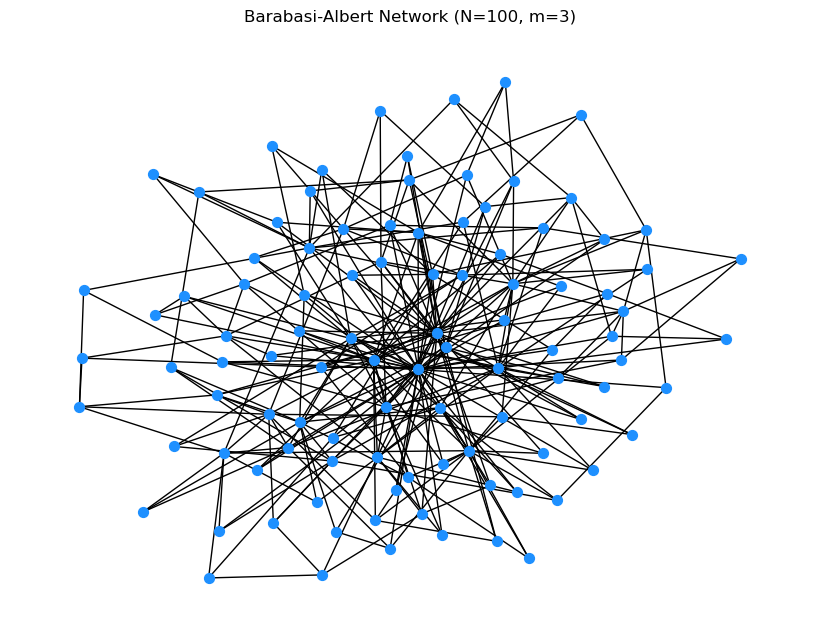

In [284]:
# Visualizing Barabasi-Albert network
plt.figure(figsize=(8, 6))
nx.draw(barabasi_albert_graph, node_size=50, node_color=COLOR_BLUE, with_labels=False)
plt.title('Barabasi-Albert Network (N=100, m=3)')
plt.show()

In [285]:
# Generating 1D regular lattice with periodic conditions
N = 10  # Number of nodes
k = 6    # Number of nearest neighbors


lattice_graph = nx.Graph()

# Create nodes and periodic edges
for i in range(N):
    lattice_graph.add_node(i)
    for j in range(1, k // 2 + 1):
        lattice_graph.add_edge(i, (i + j) % N)  # Connect to k/2 nodes on each side
        lattice_graph.add_edge(i, (i - j) % N)

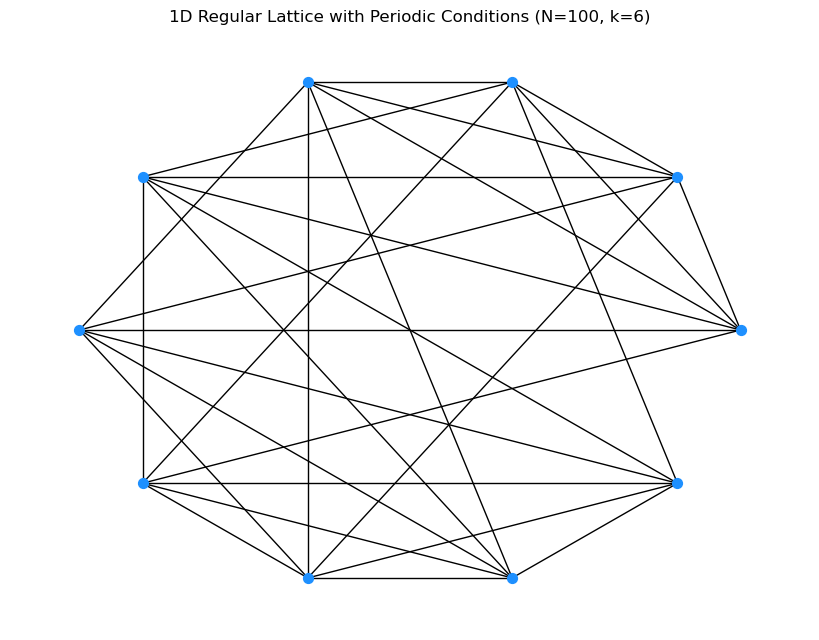

In [286]:
# Visualizing 1D regular lattice
plt.figure(figsize=(8, 6))
nx.draw_circular(lattice_graph, node_size=50, node_color=COLOR_BLUE, with_labels=False)
plt.title('1D Regular Lattice with Periodic Conditions (N=100, k=6)')
plt.show()

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_22388/607607875.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


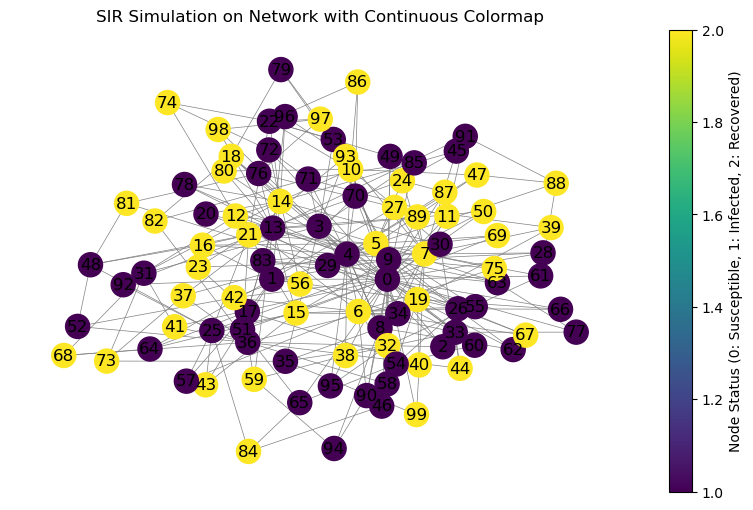

In [287]:
simulate_SIR(network=barabasi_albert_graph, infection_rate=0.3, recovery_rate=0.05, infected_seed_node=1)

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_22388/607607875.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


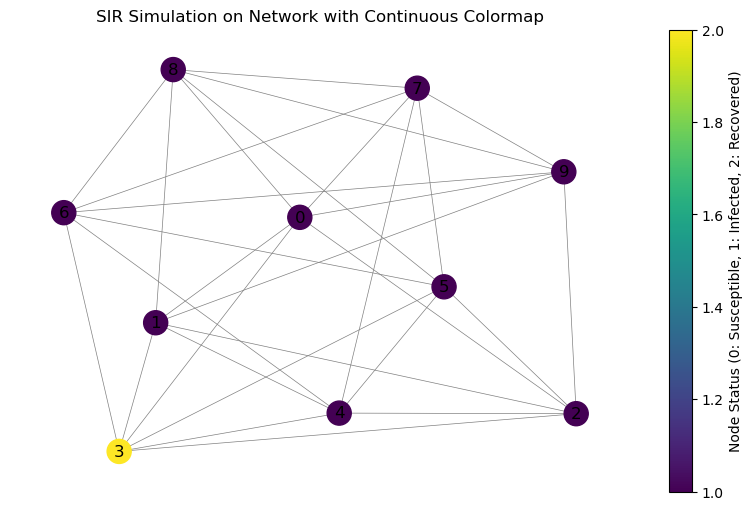

In [288]:
simulate_SIR(network=lattice_graph, infection_rate=0.5, recovery_rate=0.1, infected_seed_node=1)

In [289]:
def plot_network_state(network, node_statuses, pos, step, step_title):
    # Mapping node statuses to specific colors
    color_map = {0: COLOR_BLUE, 1: COLOR_RED, 2: COLOR_LIGHT_GRAY}

    # Get node colors based on their statuses
    node_colors = [color_map[node_statuses[node]] for node in network.nodes()]

    # Visualization with specific node colors
    plt.figure(figsize=(10, 6))
    ax = plt.subplot(111)
    #pos = nx.spring_layout(network)
    nx.draw(network, pos=pos, node_color=node_colors,
            with_labels=True, node_size=300, edge_color='gray', width=0.5, ax=ax)

    # Legend for the colors
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for status, color in color_map.items()]
    plt.legend(handles, ['Susceptible', 'Infected', 'Recovered'], loc='best')
    plt.title(f'SIR Simulation on Network with Specific Node Colors - {step_title} {step}')
    plt.show()

In [290]:
def simulate_SIR_scenario(network, infection_rate, recovery_rate, infected_seed_node, plot=False):
    """
    
    :param network: 
    :param infection_rate: 
    :param recovery_rate: 
    :param infected_seed_node: 
    :return: 
    """

    # General idea: use makers to denote status of "patients"

    # Initialize node statuses: 0 for susceptible, 1 for infected, 2 for recovered

    # SIR-model: S -> Infection => Infected -> Recovery => Recovered (immune)
    # susceptible state: describes those agents who are in a healthy state, but are prone to become ill
    # infected state: describes those agents who are under the effects of the disease
    # recovered state: describes those agents who got the disease and cannot transmit it because (e.g.) they recovered, or because they are dead

    # Infection rate Beta: probability to get infected
    # Recovery rate Gamma: probability to recover


    node_statuses = {node: 0 for node in network.nodes()} # Initiate node -> status dict
    node_statuses[infected_seed_node] = 1  # Set the seed node as infected

    susceptible_count = [len(network.nodes()) - 1]  # Initial count of susceptible nodes (excluding the seed)
    infected_count = [1]  # Initial count of infected nodes
    recovered_count = [0]  # Initial count of recovered nodes

    # Generate the initial layout of the network
    pos = nx.spring_layout(network)

    step = 0
    
    # Initialize simulation
    if plot:
        plot_network_state(network, node_statuses, pos, step, "Initial State")

    # Start simulation
    # Simulation loop
    while True:
        step += 1
        
        
        # INFECTIONS
        ###
        # Determine new infections
        new_infections = set()
        for node in network.nodes():
            # For perfromance reasons
            if node_statuses[node] == 1:  # If the node is infected
                neighbors = list(network.neighbors(node))

                # Check al neighbors if an infection happened
                for neighbor in neighbors:
                    if node_statuses[neighbor] == 0 and np.random.random() < infection_rate:
                        new_infections.add(neighbor)

        # Update statuses for new infections
        for node in new_infections:
            node_statuses[node] = 1
        ###


        # RECOVERIES
        ###
        # Determine recoveries
        recoveries = set()
        for node in network.nodes():
            if node_statuses[node] == 1:  # If the node is infected
                if np.random.random() < recovery_rate:
                    recoveries.add(node)

        # Update statuses for recoveries
        for node in recoveries:
            node_statuses[node] = 2
        ###

        # Count the number of nodes in each status
        susceptible_count.append(list(node_statuses.values()).count(0))
        infected_count.append(list(node_statuses.values()).count(1))
        recovered_count.append(list(node_statuses.values()).count(2))

        
        if plot:
            plot_network_state(network, node_statuses, pos, step, f"Step")
            
        # Stop the simulation if no new infections or recoveries occur
        if len(new_infections) == 0 and len(recoveries) == 0:
            break

    if plot:
        plot_network_state(network, node_statuses, pos, step, f"Final State")
        
        
    return {
        's_count': susceptible_count,
        'i_count': infected_count,
        'r_count': recovered_count,
        'nodes_statues': node_statuses
    }

In [291]:
simulate_SIR_scenario(network=barabasi_albert_graph, infection_rate=0.5, recovery_rate=0.1, infected_seed_node=1, plot=False)

{'s_count': [99, 92, 72, 31, 8, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'i_count': [1, 8, 24, 58, 74, 69, 65, 62, 61, 54, 45, 39, 36, 33, 27, 27],
 'r_count': [0, 0, 4, 11, 18, 27, 34, 37, 38, 45, 54, 60, 63, 66, 72, 72],
 'nodes_statues': {0: 2,
  1: 2,
  2: 2,
  3: 1,
  4: 2,
  5: 1,
  6: 2,
  7: 2,
  8: 2,
  9: 2,
  10: 2,
  11: 2,
  12: 2,
  13: 2,
  14: 2,
  15: 2,
  16: 2,
  17: 1,
  18: 1,
  19: 2,
  20: 2,
  21: 2,
  22: 2,
  23: 2,
  24: 2,
  25: 1,
  26: 2,
  27: 2,
  28: 2,
  29: 2,
  30: 1,
  31: 2,
  32: 1,
  33: 1,
  34: 2,
  35: 2,
  36: 2,
  37: 2,
  38: 1,
  39: 2,
  40: 1,
  41: 1,
  42: 2,
  43: 2,
  44: 2,
  45: 2,
  46: 2,
  47: 2,
  48: 2,
  49: 1,
  50: 2,
  51: 2,
  52: 1,
  53: 1,
  54: 2,
  55: 2,
  56: 2,
  57: 2,
  58: 2,
  59: 2,
  60: 2,
  61: 1,
  62: 2,
  63: 2,
  64: 2,
  65: 1,
  66: 1,
  67: 2,
  68: 2,
  69: 1,
  70: 2,
  71: 1,
  72: 2,
  73: 2,
  74: 2,
  75: 2,
  76: 2,
  77: 1,
  78: 2,
  79: 2,
  80: 2,
  81: 0,
  82: 1,
  83: 2,
  84: 1,
  85: 2,
  

In [292]:
def iterate_nodes_with_offset(graph, offset):
    nodes = list(graph.nodes())

    if offset >= 0:
        offset = offset % len(nodes)
        nodes_to_iterate = nodes[offset:] + nodes[:offset]
    else:
        offset = abs(offset) % len(nodes)
        nodes_to_iterate = nodes[-offset:] + nodes[:-offset]

    return nodes_to_iterate

In [293]:
def calculate_average(data):
    # Create a dictionary to store sums for each key
    sum_dict = {}

    # Loop through each dictionary in the data
    for d in data.values():
        for key, value in d.items():
            # Add the value to the sum for the corresponding key
            if key in sum_dict:
                sum_dict[key] += value
            else:
                sum_dict[key] = value

    # Calculate the average for each key
    num_dicts = len(data)
    avg_dict = {key: value / num_dicts for key, value in sum_dict.items()}

    return avg_dict

In [294]:
def simulate_SIR(network=barabasi_albert_graph, infection_rate=0.5, recovery_rate=0.1, infected_seed_node=1, plot=False, sample_size=100, seed_start=1):

    rearranged_nodes = iterate_nodes_with_offset(network, seed_start)
    
    result = {}

    # for all different seeds:
    for node in rearranged_nodes:
        print(node)
        


        aggregated_values = {}
        results = []
    
        # simulate for each starting node sample_size times
        for iteration in range(0, sample_size+1, 1):
            pass

            simulation_run = simulate_SIR_scenario(network=barabasi_albert_graph, infection_rate=infection_rate, recovery_rate=recovery_rate, infected_seed_node=infected_seed_node, plot=plot)
            results.append(simulation_run["nodes_statues"])

        for node_status in results:
            for key, value in node_status.items():
                if key not in aggregated_values:
                    aggregated_values[key] = []
                aggregated_values[key].append(value)
        
        average_values = {key: sum(values) / len(values) for key, values in aggregated_values.items()}
        result[f"starting_node_{node}"]=average_values
        #print(average_values)
    
    print(result)
    print(calculate_average(result))

In [295]:
simulate_SIR(network=barabasi_albert_graph, infection_rate=0.1, recovery_rate=0.5, infected_seed_node=1, plot=False, sample_size=10, seed_start=6)

6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
{'starting_node_6': {0: 0.18181818181818182, 1: 1.8181818181818181, 2: 0.0, 3: 0.18181818181818182, 4: 0.18181818181818182, 5: 0.36363636363636365, 6: 0.36363636363636365, 7: 0.36363636363636365, 8: 0.18181818181818182, 9: 0.5454545454545454, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.36363636363636365, 14: 0.18181818181818182, 15: 0.0, 16: 0.36363636363636365, 17: 0.36363636363636365, 18: 0.0, 19: 0.36363636363636365, 20: 0.0, 21: 0.18181818181818182, 22: 0.18181818181818182, 23: 0.18181818181818182, 24: 0.18181818181818182, 25: 0.0, 26: 0.36363636363636365, 27: 0.18181818181818182, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.18181818181818182, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.18181818

In [296]:
def simulate_SIR(network, infection_rate, recovery_rate, infected_seed_node, num_simulations=100, max_steps=100):
    """
    Simulate SIR dynamics on a network and visualize the results with a continuous colormap.

    :param network: NetworkX graph object
    :param infection_rate: Infection rate (β) beta
    :param recovery_rate: Recovery rate (γ) gamma
    :param infected_seed_node: Infected seed node
    :param num_simulations: Number of simulations to average over
    :param max_steps: Maximum number of steps for each simulation
    """
    def run_simulation():
        node_statuses = {node: 0 for node in network.nodes()}
        node_statuses[infected_seed_node] = 1

        susceptible_count = [len(network.nodes()) - 1]
        infected_count = [1]
        recovered_count = [0]

        for step in range(max_steps):
            new_infections = set()
            for node in network.nodes():
                if node_statuses[node] == 1:
                    neighbors = list(network.neighbors(node))
                    for neighbor in neighbors:
                        if node_statuses[neighbor] == 0 and np.random.random() < infection_rate:
                            new_infections.add(neighbor)

            for node in new_infections:
                node_statuses[node] = 1

            recoveries = set()
            for node in network.nodes():
                if node_statuses[node] == 1:
                    if np.random.random() < recovery_rate:
                        recoveries.add(node)

            for node in recoveries:
                node_statuses[node] = 2

            susceptible_count.append(list(node_statuses.values()).count(0))
            infected_count.append(list(node_statuses.values()).count(1))
            recovered_count.append(list(node_statuses.values()).count(2))

            if len(new_infections) == 0 and len(recoveries) == 0:
                break

        return susceptible_count, infected_count, recovered_count

    total_statuses = np.zeros((max_steps + 1, 3))

    for _ in range(num_simulations):
        susceptible, infected, recovered = run_simulation()
        total_statuses[:len(infected), :] += np.array([susceptible, infected, recovered]).T

    average_statuses = total_statuses / num_simulations

    node_status_values = average_statuses[:, 1]  # Infected status values for nodes

    norm = plt.Normalize(min(node_status_values), max(node_status_values))
    cmap = plt.cm.get_cmap('viridis')

    plt.figure(figsize=(10, 6))
    ax = plt.subplot(111)
    pos = nx.spring_layout(network)
    node_color = [node_status_values[n] for n in network.nodes()]
    nx.draw(network, pos=pos, node_color=node_color,
            cmap=cmap, node_size=100, vmin=min(node_status_values),
            vmax=max(node_status_values), edge_color='gray', width=0.5, ax=ax)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Average Infected Count')
    plt.title('SIR Simulation on Network with Continuous Colormap (Averaged over Simulations)')
    plt.show()

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_22388/3532932661.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


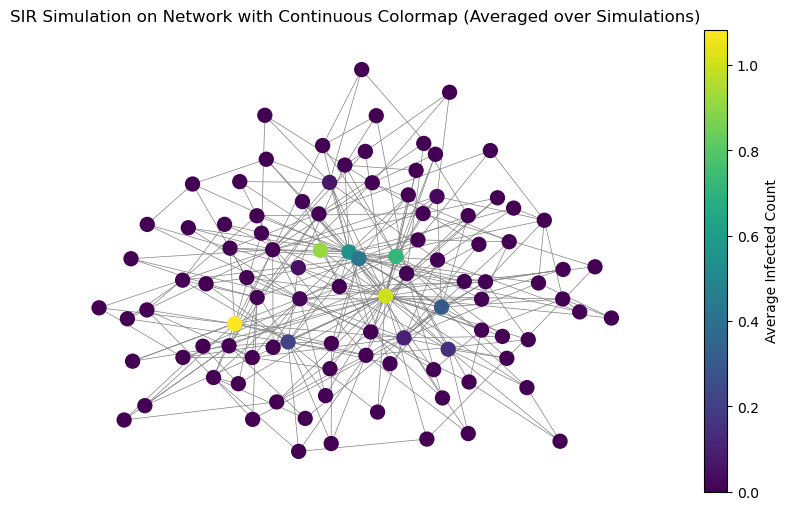

In [297]:
simulate_SIR(network=barabasi_albert_graph, infection_rate=0.1, recovery_rate=0.5, infected_seed_node=1, num_simulations=10000)